<a href="https://colab.research.google.com/github/Fabisss44/TP2-Dengue-CartografiaMultivariada-Fabiana-y-Yohel/blob/main/tp2_Dengue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =============================================================
# LABORATORIO 2: Estructura y Dependencia Espacial
# Curso: GF-0624 Cartografía Multivariada y Geovisualización
# Caso de estudio: Distribución espacial del dengue en Costa Rica (2000–2019)
# Integrantes: Fabiana Céspedes y Yohel Morales
# =============================================================
#
# Este notebook analiza si la incidencia de dengue en Costa Rica
# tiene estructura espacial o se distribuye aleatoriamente entre cantones.
# Se integran datos epidemiológicos, demográficos y ambientales
# (precipitación, temperatura y vegetación) a nivel cantonal.
#
# Fuentes de datos:
# - Dengue: PAHO (temporal.csv)
# - Población: INEC - Estimaciones y proyecciones subnacionales 2000-2050
# - Variables ambientales: Google Earth Engine (CHIRPS, CHIRTS, MODIS)
# - Geometrías: GADM nivel 2 (cantones de Costa Rica)
# =============================================================



In [44]:
# Instalación de librerías espaciales necesarias para el análisis
# geopandas: manejo de datos geográficos
# libpysal: matriz de pesos espaciales
# esda: análisis exploratorio de datos espaciales (I de Moran)
# splot: visualización de resultados espaciales
# mapclassify: clasificación de datos para mapas coropléticos

!pip install geopandas libpysal esda splot mapclassify -q
print("Librerías instaladas ✅")

Librerías instaladas ✅


In [45]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import libpysal.weights as lps
from libpysal.weights import Queen
from esda import Moran, Moran_BV
from esda.moran import Moran
from splot.esda import moran_scatterplot
import unicodedata
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente ✅")

Librerías importadas correctamente ✅


## Sección 1: Carga y Preparación del Dataset

En esta sección se integran todas las fuentes de datos necesarias
para el análisis: datos epidemiológicos de dengue, variables
ambientales y geometrías cantonales.

In [46]:
# Función para normalizar nombres de cantones
# Elimina tildes, espacios y convierte a minúsculas
# Esto es necesario para poder unir correctamente las diferentes fuentes de datos

def normalizar(texto):
    texto = str(texto).lower().strip()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    texto = texto.replace(' ', '')
    return texto

print("Función de normalización lista ✅")

Función de normalización lista ✅


### 1.1 Datos de dengue (PAHO)

Se cargan los datos de casos de dengue por cantón provistos por la
Organización Panamericana de la Salud (PAHO). El dataset contiene
registros anuales por cantón para el período 1980-2024.
Se filtra únicamente el período 2000-2019 para que coincida con
las variables ambientales disponibles, y se calcula el promedio
anual de casos por cantón como medida de resumen del período.

In [47]:
# Carga de datos de dengue desde PAHO
dengue_raw = pd.read_csv('temporal.csv')

print("Dimensiones del dataset:", dengue_raw.shape)
print("Cantones únicos:", dengue_raw['adm_2_name'].nunique())
print("Años disponibles:", sorted(dengue_raw['Year'].unique()))
dengue_raw.head()

Dimensiones del dataset: (1039, 17)
Cantones únicos: 72
Años disponibles: [np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,adm_0_name,adm_1_name,adm_2_name,full_name,ISO_A0,FAO_GAUL_code,RNE_iso_code,IBGE_code,calendar_start_date,calendar_end_date,Year,dengue_total,case_definition_standardised,S_res,T_res,UUID,region
0,COSTA RICA,CARTAGO,ALVARADO,"COSTA RICA, CARTAGO, ALVARADO",CRI,14485,CR-C,NaN,2013-01-01,2013-12-31,2013,0,Total,Admin2,Year,WHOPAHO-CRI-20132019-Y01-00,PAHO
1,COSTA RICA,GUANACASTE,CANAS,"COSTA RICA, GUANACASTE, CANAS",CRI,14495,CR-G,NaN,2013-01-01,2013-12-31,2013,2712,Total,Admin2,Year,WHOPAHO-CRI-20132019-Y01-00,PAHO
2,COSTA RICA,GUANACASTE,ABANGARES,"COSTA RICA, GUANACASTE, ABANGARES",CRI,14493,CR-G,NaN,2013-01-01,2013-12-31,2013,1068,Total,Admin2,Year,WHOPAHO-CRI-20132019-Y01-00,PAHO
3,COSTA RICA,GUANACASTE,BAGACES,"COSTA RICA, GUANACASTE, BAGACES",CRI,14494,CR-G,NaN,2013-01-01,2013-12-31,2013,1192,Total,Admin2,Year,WHOPAHO-CRI-20132019-Y01-00,PAHO
4,COSTA RICA,GUANACASTE,LIBERIA,"COSTA RICA, GUANACASTE, LIBERIA",CRI,14499,CR-G,NaN,2013-01-01,2013-12-31,2013,3630,Total,Admin2,Year,WHOPAHO-CRI-20132019-Y01-00,PAHO


In [48]:
# Filtrar período 2000-2019
dengue_filtrado = dengue_raw[
    (dengue_raw['Year'] >= 2000) &
    (dengue_raw['Year'] <= 2019)
].copy()

# Promedio anual de casos por cantón
dengue_promedio = dengue_filtrado.groupby(
    ['adm_1_name', 'adm_2_name'])['dengue_total'].mean().reset_index()
dengue_promedio.columns = ['provincia', 'canton', 'casos_promedio_anual']
dengue_promedio['canton_key'] = dengue_promedio['canton'].apply(normalizar)

print("Cantones con datos de dengue:", len(dengue_promedio))
dengue_promedio.head(10)

Cantones con datos de dengue: 72


,provincia,canton,casos_promedio_anual,canton_key
0,ALAJUELA,ALFARO RUIZ,1.600000,alfaroruiz
1,ALAJUELA,ATENAS,1336.666667,atenas
2,ALAJUELA,GRECIA,334.666667,grecia
3,ALAJUELA,GUATUSO,20.333333,guatuso
4,ALAJUELA,LOS CHILES,3.666667,loschiles
5,ALAJUELA,NARANJO,50.000000,naranjo
6,ALAJUELA,OROTINA,719.000000,orotina
7,ALAJUELA,PALMARES,33.666667,palmares
8,ALAJUELA,POAS,119.333333,poas
9,ALAJUELA,SAN CARLOS,247.333333,sancarlos


### 1.2 Datos de población por cantón (INEC)

Se cargan las estimaciones y proyecciones de población cantonal
del Instituto Nacional de Estadística y Censos (INEC) de Costa Rica,
correspondientes al período 2000-2050. Se utiliza el promedio de
población del período 2000-2019 para calcular la tasa de incidencia
de dengue por 100.000 habitantes, que permite comparar cantones
de diferente tamaño poblacional.

In [52]:
# Cargar Excel del INEC - pestaña C4 (población total por cantón 2000-2050)
poblacion_raw = pd.read_excel(
    'poblacion.xlsx',
    sheet_name='C4',
    header=4,
    engine='openpyxl'
)

print("Dimensiones:", poblacion_raw.shape)
poblacion_raw.head(3)

Dimensiones: (433, 36)


,Unnamed: 0,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2001.2,2002.2,2003.2,2004.2,2005.2,2006.2,2007.2,2008.2,2009.2,Unnamed: 35
0,101_San José,294065.002318,296962.366057,299519.570023,302100.375231,304758.990031,307513.969713,310438.658022,313591.506167,316897.464942,...,152513.295984,153736.499429,154982.770942,156271.784519,157616.571408,159048.432081,160578.892978,162178.485522,163737.783073,NaN
1,102_Escazú,54606.646999,55629.376658,56562.953992,57489.099277,58398.323728,59281.081924,60150.488523,61020.119811,61876.945707,...,28448.809493,28913.930474,29378.499436,29834.607513,30278.048872,30715.844936,31151.793693,31581.165975,31984.644763,NaN
2,103_Desamparados,189403.545757,192530.466142,195359.828152,198169.271077,200951.090898,203697.036278,206465.503857,209305.117125,212169.195588,...,97603.157937,98969.844761,100338.464203,101695.850122,103039.744197,104400.540518,105794.016074,107201.356197,108556.851606,NaN


In [53]:
# Limpiar y procesar población
pob = poblacion_raw.rename(columns={'Unnamed: 0': 'canton_raw'}).copy()
pob = pob[pob['canton_raw'].astype(str).str.match(r'^\d{3}_')]
pob = pob.head(84)

pob['codigo_canton'] = pob['canton_raw'].astype(str).str.extract(r'^(\d+)').astype(int)
pob['canton'] = pob['canton_raw'].astype(str).str.replace(r'^\d+_', '', regex=True).str.strip()

años = [y for y in range(2000, 2020) if y in pob.columns]
pob['poblacion_promedio'] = pob[años].mean(axis=1).astype(int)
pob['canton_key'] = pob['canton'].apply(normalizar)

poblacion = pob[['codigo_canton', 'canton', 'canton_key', 'poblacion_promedio']].reset_index(drop=True)

print("Cantones con población:", len(poblacion))
poblacion.head(10)

Cantones con población: 84


,codigo_canton,canton,canton_key,poblacion_promedio
0,101,San José,sanjose,306597
1,102,Escazú,escazu,58769
2,103,Desamparados,desamparados,202296
3,104,Puriscal,puriscal,32269
4,105,Tarrazú,tarrazu,15237
5,106,Aserrí,aserri,52442
6,107,Mora,mora,25338
7,108,Goicoechea,goicoechea,118327
8,109,Santa Ana,santaana,47001
9,110,Alajuelita,alajuelita,73466


### 1.3 Variables ambientales

Se cargan las tres variables ambientales procesadas desde Google Earth Engine:
temperatura superficial terrestre (LST), índice de vegetación NDVI
y precipitación (CHIRPS). Estas variables son relevantes porque el
mosquito Aedes aegypti, transmisor del dengue, depende de condiciones
específicas de temperatura, humedad y vegetación para reproducirse.

In [54]:
# Temperatura promedio por cantón
temperatura = pd.read_csv('temp_por_canton.csv')
temperatura['canton_key'] = temperatura['canton'].apply(normalizar)

# NDVI promedio por cantón
ndvi = pd.read_csv('ndvi_por_canton.csv')
ndvi['canton_key'] = ndvi['canton'].apply(normalizar)

print("Temperatura - cantones:", len(temperatura))
print("NDVI - cantones:", len(ndvi))
temperatura.head(5)

Temperatura - cantones: 84
NDVI - cantones: 84


,codigo_canton,canton,temp_promedio,canton_key
0,101,San José,26.744594,sanjose
1,102,Escazú,26.307541,escazu
2,103,Desamparados,24.753831,desamparados
3,104,Puriscal,29.964330,puriscal
4,105,Tarrazú,26.336759,tarrazu


In [55]:
# Cargar precipitación diaria CHIRPS
print("Cargando precipitación (puede tardar unos segundos)...")
chirps = pd.read_csv('chirpsCB_AllCantons.csv')

# Extraer año desde el índice temporal
chirps['fecha'] = chirps['system:index'].str.extract(r'(\d{8})$')
chirps['año'] = chirps['fecha'].str[:4].astype(int)

# Filtrar 2000-2019 y calcular promedio anual por cantón
chirps_filtrado = chirps[(chirps['año'] >= 2000) & (chirps['año'] <= 2019)]
chirps_anual = chirps_filtrado.groupby(
    ['CÓDIGO_CA', 'CANTÓN', 'año'])['meanrain'].sum().reset_index()
precipitacion = chirps_anual.groupby(
    ['CÓDIGO_CA', 'CANTÓN'])['meanrain'].mean().reset_index()
precipitacion.columns = ['codigo_canton', 'canton', 'precip_promedio']
precipitacion['canton_key'] = precipitacion['canton'].apply(normalizar)

print("Cantones con precipitación:", len(precipitacion))
precipitacion.head(5)

Cargando precipitación (puede tardar unos segundos)...
Cantones con precipitación: 84


,codigo_canton,canton,precip_promedio,canton_key
0,101,San José,1708.758911,sanjose
1,102,Escazú,1966.295494,escazu
2,103,Desamparados,1969.986926,desamparados
3,104,Puriscal,2782.156661,puriscal
4,105,Tarrazú,3244.362653,tarrazu


### 1.4 Geometrías de cantones de Costa Rica (SNIT)

Se carga el shapefile oficial de límites cantonales descargado del
Sistema Nacional de Información Territorial (SNIT) de Costa Rica.
Este shapefile contiene las geometrías de los 84 cantones del país
y es la fuente oficial del gobierno costarricense para datos geoespaciales.
A diferencia de fuentes internacionales, este shapefile usa los nombres
y códigos oficiales del país, lo que facilita la unión con otras
fuentes de datos nacionales.

In [56]:
# Cargar shapefile oficial de cantones del SNIT
cantones = gpd.read_file('limitecantonal_5k.shp')

# Reproyectar a WGS84 para compatibilidad
cantones = cantones.to_crs(epsg=4326)

# Normalizar nombres
cantones['canton_key'] = cantones['CANTÓN'].apply(normalizar)

print("Cantones cargados:", len(cantones))
print("CRS:", cantones.crs)
cantones[['CÓDIGO_CAN', 'CANTÓN', 'PROVINCIA', 'canton_key']].head(10)

Cantones cargados: 84
CRS: EPSG:4326


,CÓDIGO_CAN,CANTÓN,PROVINCIA,canton_key
0,101,San José,San José,sanjose
1,102,Escazú,San José,escazu
2,103,Desamparados,San José,desamparados
3,104,Puriscal,San José,puriscal
4,105,Tarrazú,San José,tarrazu
5,106,Aserrí,San José,aserri
6,107,Mora,San José,mora
7,108,Goicoechea,San José,goicoechea
8,109,Santa Ana,San José,santaana
9,110,Alajuelita,San José,alajuelita


### 1.5 Integración del dataset final

Se unen todas las fuentes de datos en un único GeoDataFrame de trabajo.
La unión se realiza por nombre de cantón normalizado (sin tildes,
sin espacios, en minúsculas) para evitar problemas de compatibilidad
entre fuentes. Finalmente se calcula la tasa de incidencia de dengue
por 100.000 habitantes, variable estándar en epidemiología que permite
comparar cantones con poblaciones muy diferentes entre sí.

Fórmula: tasa = (casos_promedio_anual / poblacion_promedio) × 100.000

In [57]:
# Unir todas las fuentes al shapefile base
gdf = cantones.copy()

# Dengue
gdf = gdf.merge(dengue_promedio[['canton_key','casos_promedio_anual']],
                on='canton_key', how='left')

# Población
gdf = gdf.merge(poblacion[['canton_key','poblacion_promedio']],
                on='canton_key', how='left')

# Temperatura
gdf = gdf.merge(temperatura[['canton_key','temp_promedio']],
                on='canton_key', how='left')

# NDVI
gdf = gdf.merge(ndvi[['canton_key','ndvi_promedio']],
                on='canton_key', how='left')

# Precipitación
gdf = gdf.merge(precipitacion[['canton_key','precip_promedio']],
                on='canton_key', how='left')

# Calcular tasa de incidencia por 100.000 habitantes
gdf['tasa_incidencia'] = (gdf['casos_promedio_anual'] / gdf['poblacion_promedio']) * 100000

print("Dimensiones del GeoDataFrame:", gdf.shape)
print("\nValores faltantes por columna:")
print(gdf[['casos_promedio_anual','poblacion_promedio','temp_promedio',
           'ndvi_promedio','precip_promedio','tasa_incidencia']].isna().sum())

Dimensiones del GeoDataFrame: (84, 26)

Valores faltantes por columna:
casos_promedio_anual    15
poblacion_promedio       3
temp_promedio            0
ndvi_promedio            0
precip_promedio          0
tasa_incidencia         15
dtype: int64


In [58]:
# Vista general del GeoDataFrame final
columnas_analisis = ['CANTÓN', 'PROVINCIA', 'casos_promedio_anual',
                     'poblacion_promedio', 'tasa_incidencia',
                     'temp_promedio', 'ndvi_promedio', 'precip_promedio']

print("=== GEODATAFRAME FINAL ===")
print(f"Cantones totales: {len(gdf)}")
print(f"Cantones con datos completos: {gdf[columnas_analisis].dropna().shape[0]}")
print()
gdf[columnas_analisis].head(10)

=== GEODATAFRAME FINAL ===
Cantones totales: 84
Cantones con datos completos: 69



,CANTÓN,PROVINCIA,casos_promedio_anual,poblacion_promedio,tasa_incidencia,temp_promedio,ndvi_promedio,precip_promedio
0,San José,San José,78.000000,306597.0,25.440562,26.744594,3497.422850,1708.758911
1,Escazú,San José,25.666667,58769.0,43.673819,26.307541,5350.726571,1966.295494
2,Desamparados,San José,389.000000,202296.0,192.292482,24.753831,6700.319914,1969.986926
3,Puriscal,San José,208.000000,32269.0,644.581487,29.964330,7327.744746,2782.156661
4,Tarrazú,San José,NaN,15237.0,NaN,26.336759,6883.206848,3244.362653
5,Aserrí,San José,57.666667,52442.0,109.962753,25.569756,6841.017415,2849.671002
6,Mora,San José,239.666667,25338.0,945.878391,28.505019,7379.446275,2485.711549
7,Goicoechea,San José,85.333333,118327.0,72.116536,23.876621,5057.528770,2130.014296
8,Santa Ana,San José,138.000000,47001.0,293.610774,26.925833,6027.511248,2170.070112
9,Alajuelita,San José,108.666667,73466.0,147.914228,25.477487,5573.675498,1998.736883


## Sección 2: Análisis Exploratorio de Datos Espaciales (ESDA)

En esta sección se realiza un análisis exploratorio completo de cada variable.
El objetivo es entender la distribución, identificar outliers y visualizar
los patrones espaciales antes de calcular cualquier índice de autocorrelación.
El ESDA es un paso fundamental porque permite conocer los datos antes de
aplicar técnicas estadísticas más complejas.

In [59]:
# ---------------------------------------------------------------
# SECCIÓN 2: ESDA
# ---------------------------------------------------------------
# Estadística descriptiva de todas las variables de análisis
# Se usa solo el subconjunto de cantones con datos completos

gdf_c = gdf.dropna(subset=['tasa_incidencia', 'temp_promedio',
                             'ndvi_promedio', 'precip_promedio']).copy()
gdf_c = gdf_c.reset_index(drop=True)

variables = {
    'Tasa incidencia dengue\n(por 100k hab)': 'tasa_incidencia',
    'Temperatura (°C)': 'temp_promedio',
    'NDVI': 'ndvi_promedio',
    'Precipitación (mm)': 'precip_promedio'
}

resumen = {}
for nombre, col in variables.items():
    serie = gdf_c[col].dropna()
    resumen[nombre] = {
        'n': serie.count(),
        'media': round(serie.mean(), 3),
        'mediana': round(serie.median(), 3),
        'desv. estándar': round(serie.std(), 3),
        'mínimo': round(serie.min(), 3),
        'máximo': round(serie.max(), 3),
        'asimetría': round(stats.skew(serie), 3)
    }

df_resumen = pd.DataFrame(resumen).T
print("=== ESTADÍSTICA DESCRIPTIVA ===\n")
display(df_resumen)

=== ESTADÍSTICA DESCRIPTIVA ===



,n,media,mediana,desv. estándar,mínimo,máximo,asimetría
Tasa incidencia dengue\n(por 100k hab),69.0,1272.856,508.431,1492.605,0.000,5386.744,1.212
Temperatura (°C),69.0,18.201,26.308,30.755,-188.497,33.399,-4.885
NDVI,69.0,6491.308,6814.842,983.799,3393.253,7614.394,-1.409
Precipitación (mm),69.0,2555.577,2305.723,672.430,1675.917,4039.394,0.832


### 2.2 Distribuciones e identificación de outliers

Se analizan los histogramas y boxplots de cada variable para identificar
la forma de la distribución, posibles outliers y asimetrías. Esta información
es importante porque variables con distribuciones muy sesgadas pueden
requerir transformaciones antes del análisis espacial.

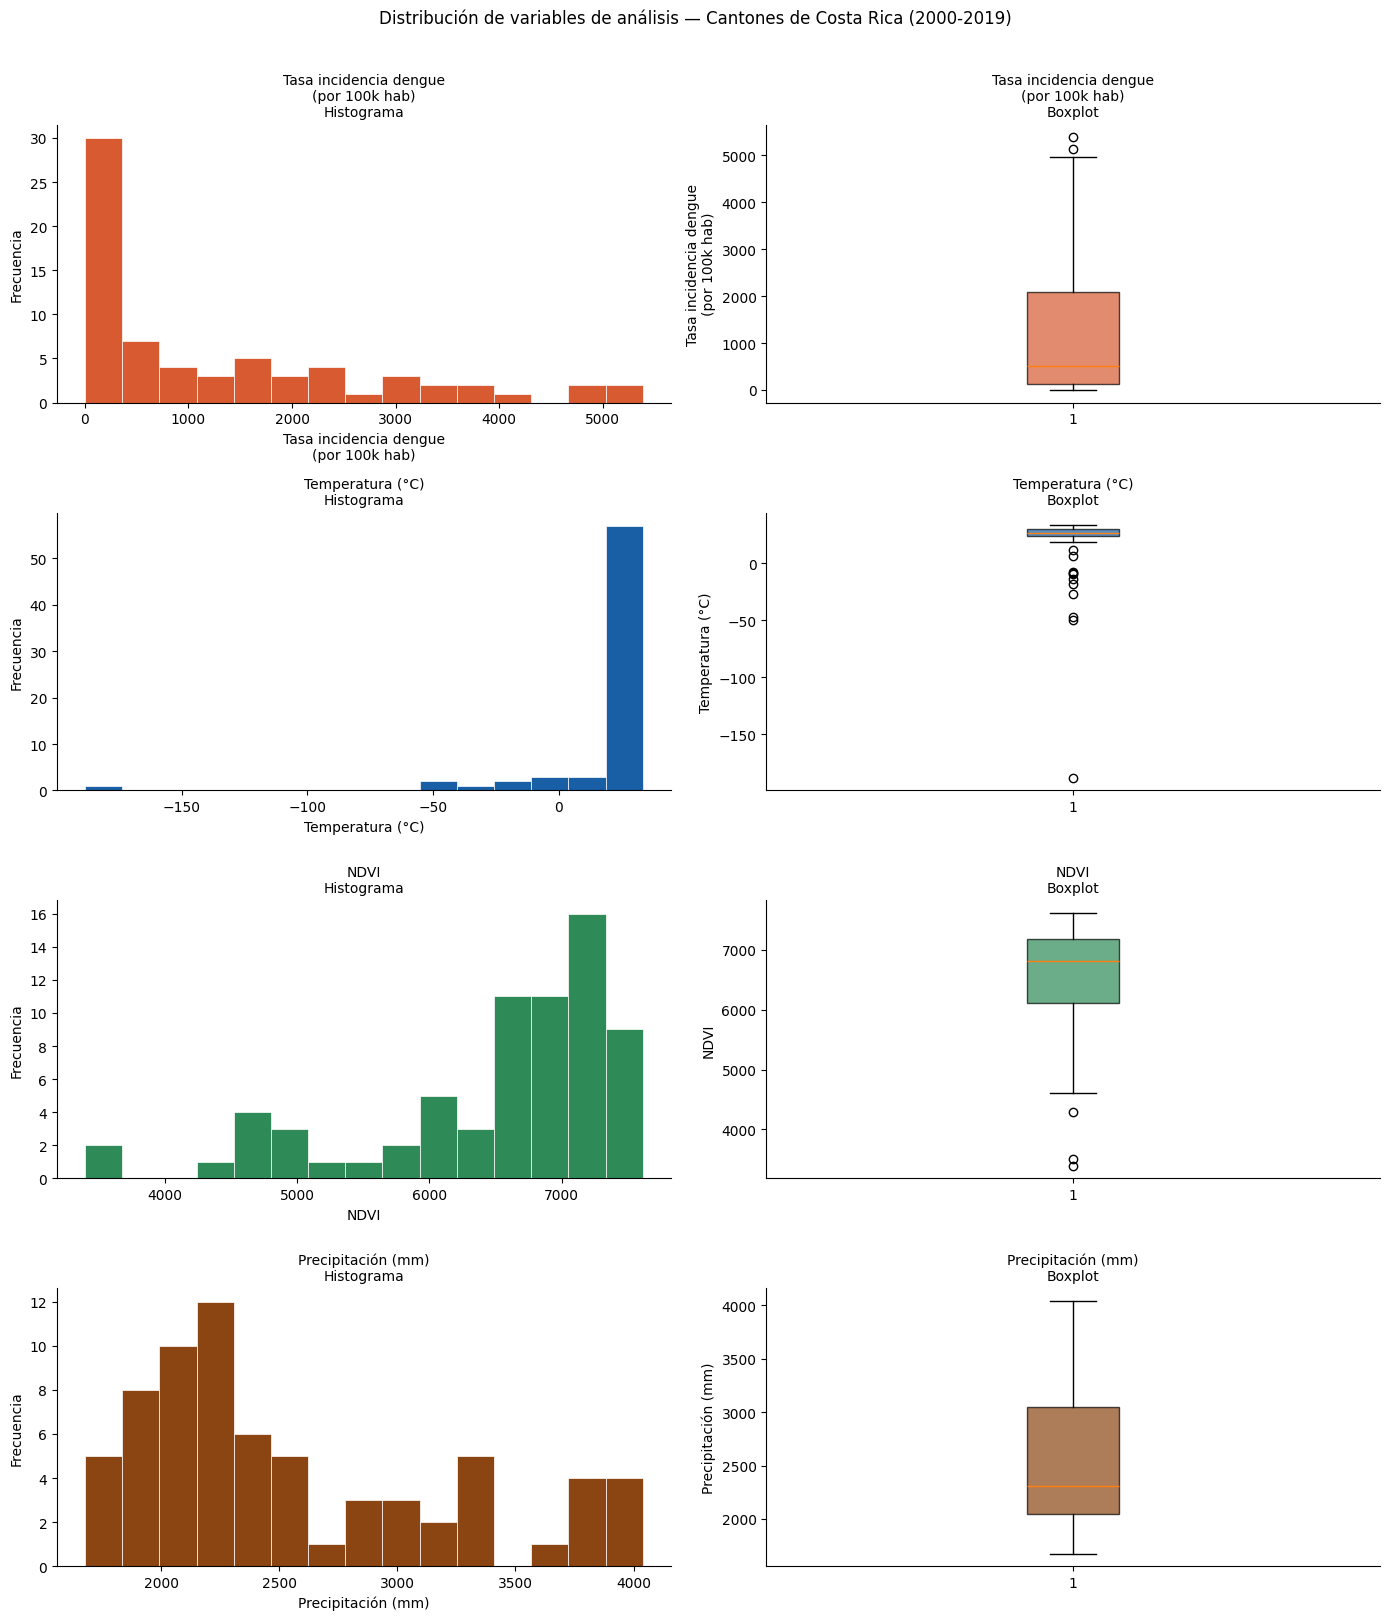

In [60]:
# Histogramas y boxplots para cada variable
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

colores = ['#D85A30', '#185FA5', '#2E8B57', '#8B4513']

for i, (nombre, col) in enumerate(variables.items()):
    serie = gdf_c[col].dropna()

    # Histograma
    axes[i, 0].hist(serie, bins=15, color=colores[i],
                    edgecolor='white', linewidth=0.5)
    axes[i, 0].set_title(f'{nombre}\nHistograma', fontsize=10)
    axes[i, 0].set_xlabel(nombre)
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].spines[['top', 'right']].set_visible(False)

    # Boxplot
    axes[i, 1].boxplot(serie, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=colores[i], alpha=0.7))
    axes[i, 1].set_title(f'{nombre}\nBoxplot', fontsize=10)
    axes[i, 1].set_ylabel(nombre)
    axes[i, 1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Distribución de variables de análisis — Cantones de Costa Rica (2000-2019)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Identificación de outliers

Se identifican los cantones con valores extremos en cada variable.
Los outliers son importantes porque pueden influir significativamente
en el cálculo del I de Moran y en la interpretación de los patrones espaciales.

In [61]:
# Top 5 y bottom 5 cantones por cada variable
for nombre, col in variables.items():
    print(f"\n=== {nombre} ===")
    top5 = gdf_c[['CANTÓN', 'PROVINCIA', col]].nlargest(5, col)
    bot5 = gdf_c[['CANTÓN', 'PROVINCIA', col]].nsmallest(5, col)
    print("Top 5 más altos:")
    print(top5.to_string(index=False))
    print("Top 5 más bajos:")
    print(bot5.to_string(index=False))


=== Tasa incidencia dengue
(por 100k hab) ===
Top 5 más altos:
       CANTÓN  PROVINCIA  tasa_incidencia
       Atenas   Alajuela      5386.744042
    Abangares Guanacaste      5148.027258
Montes de Oro Puntarenas      4972.045812
      Parrita Puntarenas      4859.589723
       Nicoya Guanacaste      4031.851837
Top 5 más bajos:
    CANTÓN PROVINCIA  tasa_incidencia
   Jiménez   Cartago         0.000000
  Alvarado   Cartago         0.000000
 El Guarco   Cartago        14.139272
Los Chiles  Alajuela        15.186029
  La Unión   Cartago        18.147305

=== Temperatura (°C) ===
Top 5 más altos:
    CANTÓN  PROVINCIA  temp_promedio
Los Chiles   Alajuela      33.399276
   Bagaces Guanacaste      33.339158
     Cañas Guanacaste      33.149899
   Liberia Guanacaste      33.074765
    Nicoya Guanacaste      32.978299
Top 5 más bajos:
   CANTÓN  PROVINCIA  temp_promedio
Nandayure Guanacaste    -188.497070
 Garabito Puntarenas     -49.781453
 Carrillo Guanacaste     -47.646207
  La Cruz Gua

### 2.4 Mapas coropléticos

Los mapas coropléticos permiten visualizar la distribución espacial
de cada variable. Se usa clasificación por cuantiles (quintiles) para
que cada clase tenga aproximadamente el mismo número de cantones,
lo que facilita la comparación visual entre variables.
La clasificación por cuantiles es apropiada cuando los datos tienen
distribuciones asimétricas, como es el caso de la tasa de incidencia
de dengue.

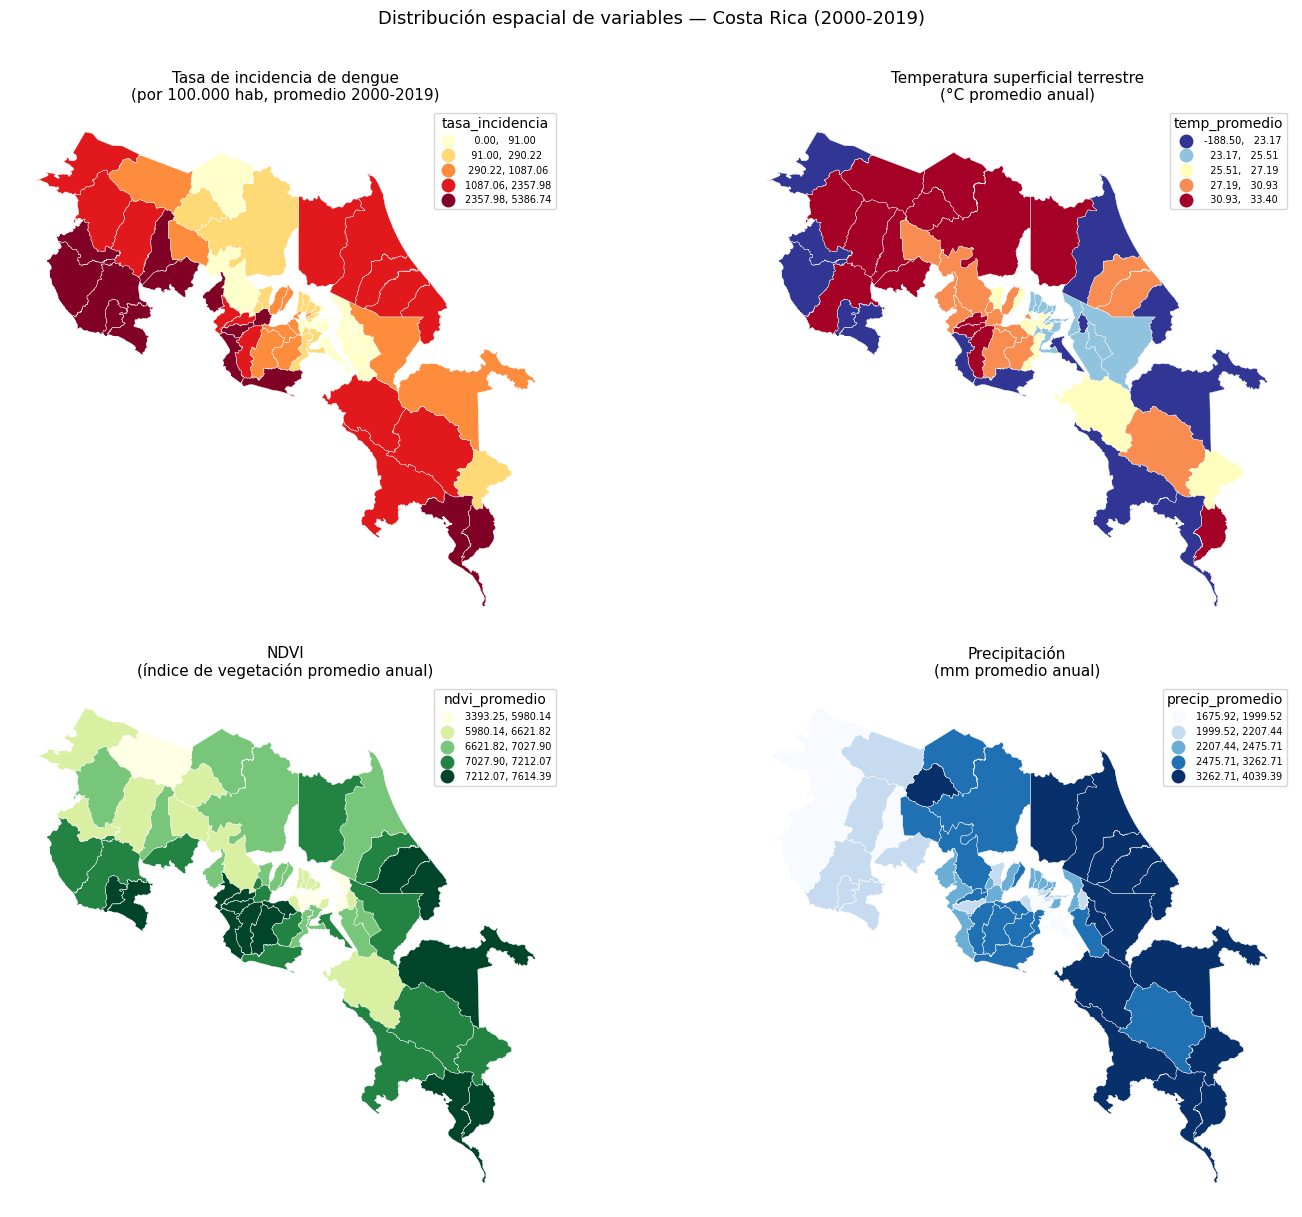

In [62]:
# Mapas coropléticos de las 4 variables principales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

titulos = [
    'Tasa de incidencia de dengue\n(por 100.000 hab, promedio 2000-2019)',
    'Temperatura superficial terrestre\n(°C promedio anual)',
    'NDVI\n(índice de vegetación promedio anual)',
    'Precipitación\n(mm promedio anual)'
]
cmaps = ['YlOrRd', 'RdYlBu_r', 'YlGn', 'Blues']

for i, (col, titulo, cmap) in enumerate(zip(
    ['tasa_incidencia', 'temp_promedio', 'ndvi_promedio', 'precip_promedio'],
    titulos, cmaps)):

    gdf_c.plot(column=col, cmap=cmap, scheme='quantiles', k=5,
               legend=True, edgecolor='white', linewidth=0.3,
               ax=axes[i], missing_kwds={'color': 'lightgrey'},
               legend_kwds={'title': col, 'fontsize': 7})
    axes[i].set_title(titulo, fontsize=11)
    axes[i].axis('off')

plt.suptitle('Distribución espacial de variables — Costa Rica (2000-2019)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Sección 3: Matriz de Pesos Espaciales W

La matriz de pesos espaciales W define quiénes son los vecinos de cada cantón
y con qué peso se considera esa vecindad. Esta matriz es fundamental para
todos los análisis de autocorrelación espacial posteriores.

Se construye una matriz de contigüidad tipo Queen, que considera vecinos
a todos los cantones que comparten un borde o un vértice. Este criterio
es el más apropiado para el análisis de dengue porque las enfermedades
infecciosas no respetan límites administrativos estrictos — un cantón
puede influir en todos sus vecinos, independientemente de si comparten
un borde largo o solo un punto.

Importante: el análisis trabaja con 69 cantones (subconjunto con datos
completos), no con los 84 cantones del país. Esto puede generar que
algunos cantones queden con menos vecinos de los que tendrían en realidad,
lo que se discute en la sección de limitaciones.

In [63]:
# ---------------------------------------------------------------
# SECCIÓN 3: MATRIZ DE PESOS ESPACIALES W
# ---------------------------------------------------------------
# Construcción de matriz de contigüidad tipo Queen
# Queen: vecinos = cantones que comparten borde O vértice

w = Queen.from_dataframe(gdf_c, silence_warnings=True)
w.transform = 'r'  # Estandarización por fila (cada fila suma 1)

print("=== MATRIZ DE PESOS ESPACIALES W (Queen) ===")
print(f"Cantones en la matriz: {w.n}")
print(f"Promedio de vecinos por cantón: {w.mean_neighbors:.2f}")
print(f"Mínimo de vecinos: {min(w.cardinalities.values())}")
print(f"Máximo de vecinos: {max(w.cardinalities.values())}")
print(f"Cantones sin vecinos (islas): {sum(1 for v in w.cardinalities.values() if v == 0)}")

# Calcular lag espacial de la tasa de incidencia
gdf_c['dengue_lag'] = w.sparse.dot(gdf_c['tasa_incidencia'].fillna(0).values)

=== MATRIZ DE PESOS ESPACIALES W (Queen) ===
Cantones en la matriz: 69
Promedio de vecinos por cantón: 4.17
Mínimo de vecinos: 1
Máximo de vecinos: 10
Cantones sin vecinos (islas): 0


### 3.2 Visualización de la matriz de vecindad

Se visualiza la red de vecindad para verificar que la matriz W
fue construida correctamente y que no hay cantones aislados
dentro del subconjunto de análisis.

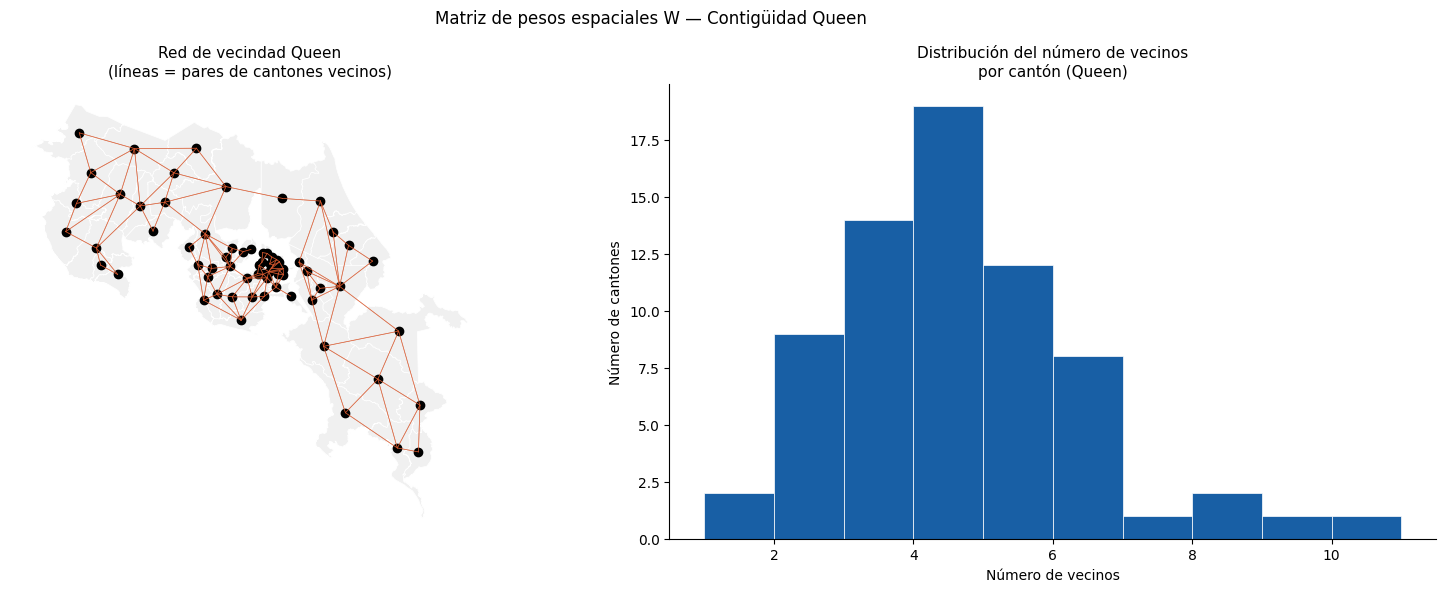

In [64]:
# Visualizar red de vecindad sobre el mapa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mapa de cantones con red de vecindad
gdf_c.plot(ax=axes[0], color='#f0f0f0', edgecolor='white', linewidth=0.5)
w.plot(gdf_c, ax=axes[0], edge_kws=dict(color='#D85A30', linewidth=0.5, alpha=0.7))
axes[0].set_title('Red de vecindad Queen\n(líneas = pares de cantones vecinos)',
                   fontsize=11)
axes[0].axis('off')

# Histograma del número de vecinos por cantón
vecinos = list(w.cardinalities.values())
axes[1].hist(vecinos, bins=range(1, max(vecinos)+2),
             color='#185FA5', edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribución del número de vecinos\npor cantón (Queen)', fontsize=11)
axes[1].set_xlabel('Número de vecinos')
axes[1].set_ylabel('Número de cantones')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Matriz de pesos espaciales W — Contigüidad Queen', fontsize=12)
plt.tight_layout()
plt.show()

## Sección 4: I de Moran Global Univariada

El I de Moran es el índice más utilizado para medir la autocorrelación
espacial global. Mide si los cantones con valores similares tienden a
estar cerca entre sí (autocorrelación positiva) o si los cantones con
valores similares tienden a estar alejados (autocorrelación negativa).

Hipótesis nula: los valores están distribuidos aleatoriamente en el espacio.
Nivel de significancia: α = 0.05

Interpretación:
- I positiva y significativa → los cantones con valores similares se agrupan
- I cercana a 0 → distribución aleatoria
- I negativa → los cantones con valores similares se dispersan

In [65]:
# ---------------------------------------------------------------
# SECCIÓN 4: I DE MORAN GLOBAL
# ---------------------------------------------------------------
# Cálculo del I de Moran para dengue y variables ambientales

variables_moran = {
    'Tasa incidencia dengue': 'tasa_incidencia',
    'Temperatura (°C)': 'temp_promedio',
    'NDVI': 'ndvi_promedio',
    'Precipitación (mm)': 'precip_promedio'
}

resultados_moran = {}
for nombre, col in variables_moran.items():
    serie = gdf_c[col].fillna(gdf_c[col].mean())
    m = Moran(serie, w, permutations=999)
    resultados_moran[nombre] = {
        'I de Moran': round(m.I, 4),
        'z-score': round(m.z_norm, 4),
        'p-value': round(m.p_norm, 4),
        'Significativo (α=0.05)': 'Sí ✓' if m.p_norm < 0.05 else 'No'
    }

df_moran = pd.DataFrame(resultados_moran).T
print("=== I DE MORAN GLOBAL ===\n")
display(df_moran)

=== I DE MORAN GLOBAL ===



,I de Moran,z-score,p-value,Significativo (α=0.05)
Tasa incidencia dengue,0.3942,4.7869,0.0,Sí ✓
Temperatura (°C),0.0524,0.7853,0.4323,No
NDVI,0.64,7.6647,0.0,Sí ✓
Precipitación (mm),0.727,8.6827,0.0,Sí ✓


### 4.1 Interpretación del I de Moran Global

| Variable | I de Moran | z-score | p-value | Interpretación |
|---|---|---|---|---|
| Tasa incidencia dengue | 0.3942 | 4.7869 | 0.0000 | Autocorrelación positiva significativa |
| Temperatura (°C) | 0.0524 | 0.7853 | 0.4323 | Sin autocorrelación significativa |
| NDVI | 0.6400 | 7.6647 | 0.0000 | Autocorrelación positiva muy fuerte |
| Precipitación (mm) | 0.7270 | 8.6827 | 0.0000 | Autocorrelación positiva muy fuerte |

**Dengue (I = 0.3942, p < 0.05):** La tasa de incidencia de dengue presenta
autocorrelación espacial positiva y estadísticamente significativa. Esto indica
que los cantones con tasas similares de dengue tienden a agruparse espacialmente.
El patrón observado no es compatible con una distribución aleatoria, lo que sugiere
que factores ambientales, ecológicos o epidemiológicos con continuidad territorial
condicionan la distribución del dengue entre cantones vecinos.

**Temperatura (I = 0.0524, p = 0.4323):** La temperatura no presenta autocorrelación
espacial significativa a nivel cantonal. Esto puede deberse a que Costa Rica tiene
una topografía muy variada: cantones vecinos pueden tener temperaturas muy diferentes
dependiendo de su altitud, lo que rompe el patrón de agrupamiento espacial.

**NDVI (I = 0.6400, p < 0.05):** El índice de vegetación presenta una autocorrelación
espacial positiva muy fuerte. Los cantones con alta cobertura vegetal tienden a estar
rodeados de cantones también con alta vegetación, lo que refleja la continuidad
de los ecosistemas forestales y agrícolas en el territorio costarricense.

**Precipitación (I = 0.7270, p < 0.05):** La precipitación es la variable con mayor
autocorrelación espacial. Esto es ecológicamente coherente: los regímenes de lluvia
en Costa Rica responden a patrones climáticos regionales (vertiente Pacífica vs
vertiente Caribe) que tienen fuerte continuidad espacial entre cantones vecinos.

### 4.2 Moran Scatterplot

El Moran Scatterplot relaciona el valor estandarizado de cada cantón
con el lag espacial de sus vecinos (promedio ponderado de los vecinos).
La pendiente de la recta de regresión es aproximadamente igual al I de Moran.

Los cuatro cuadrantes representan:
- Alto-Alto (HH): cantones con valores altos rodeados de vecinos con valores altos
- Bajo-Bajo (LL): cantones con valores bajos rodeados de vecinos con valores bajos  
- Alto-Bajo (HL): cantones con valores altos rodeados de vecinos con valores bajos
- Bajo-Alto (LH): cantones con valores bajos rodeados de vecinos con valores altos

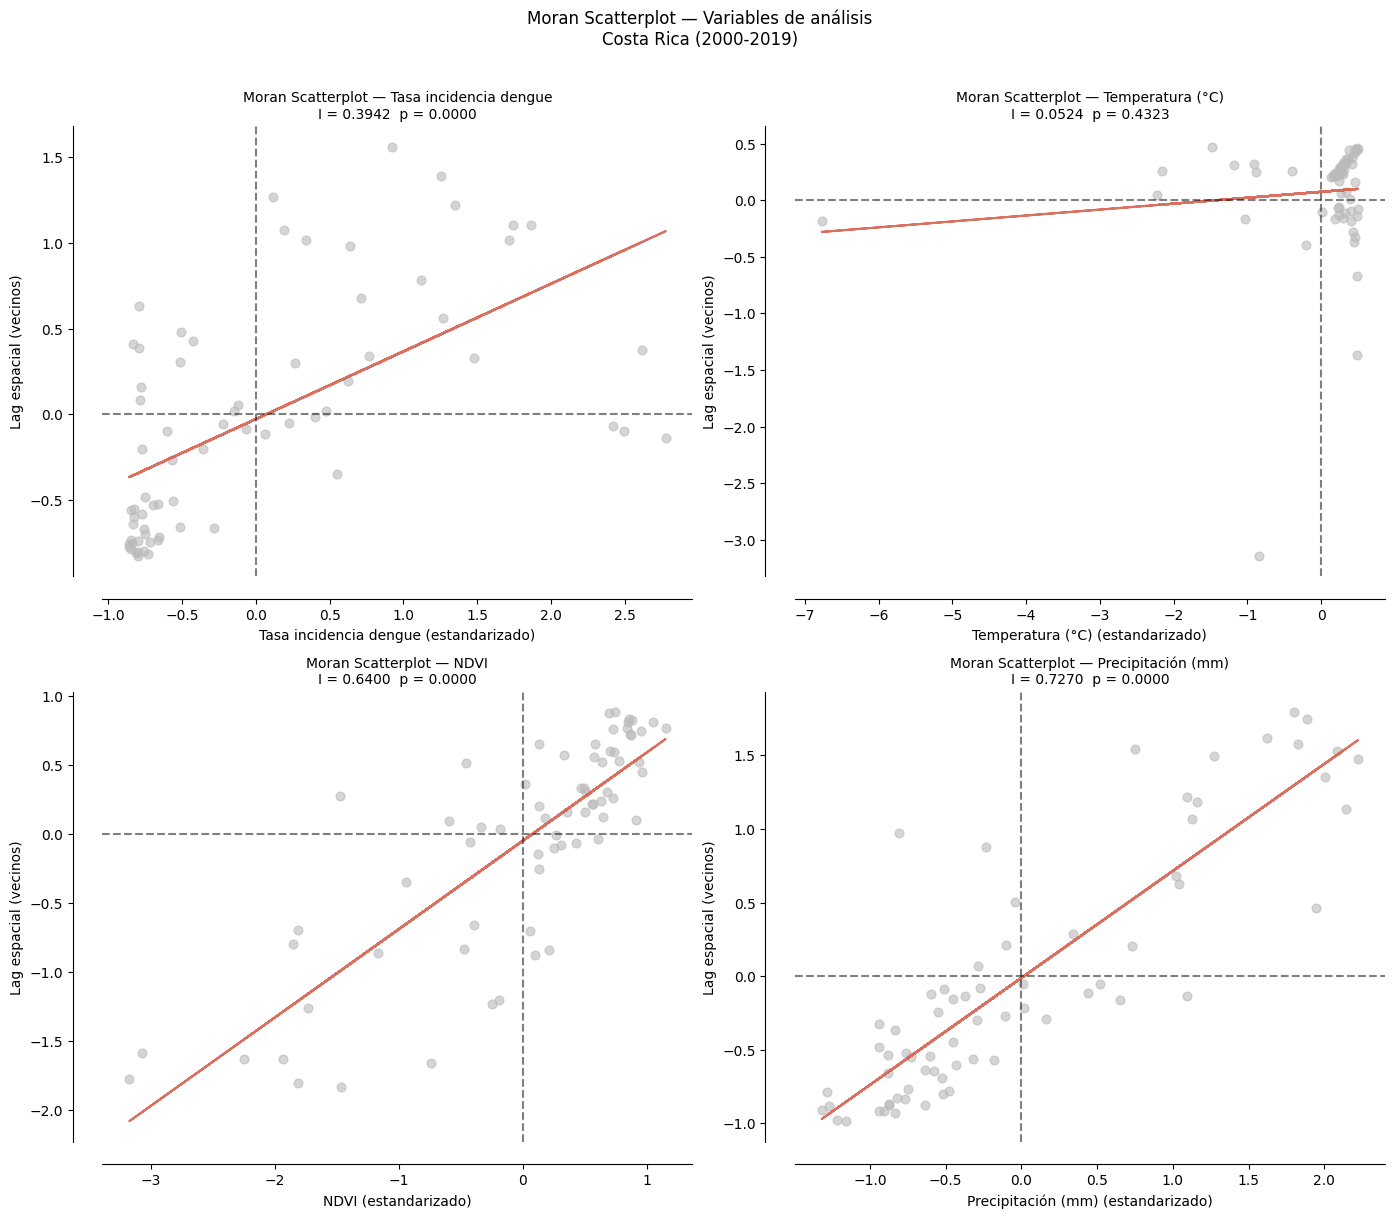

In [66]:
# Moran Scatterplot para cada variable
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (nombre, col) in enumerate(variables_moran.items()):
    serie = gdf_c[col].fillna(gdf_c[col].mean())
    m = Moran(serie, w, permutations=999)
    moran_scatterplot(m, ax=axes[i], aspect_equal=False)
    axes[i].set_title(f'Moran Scatterplot — {nombre}\nI = {m.I:.4f}  p = {m.p_norm:.4f}',
                      fontsize=10)
    axes[i].set_xlabel(f'{nombre} (estandarizado)')
    axes[i].set_ylabel('Lag espacial (vecinos)')

plt.suptitle('Moran Scatterplot — Variables de análisis\nCosta Rica (2000-2019)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Cantones por cuadrante del Moran Scatterplot

Se identifican los cantones que aparecen en cada cuadrante del
Moran Scatterplot para la tasa de incidencia de dengue.
Esto permite identificar territorialmente dónde se concentran
los clusters y los outliers espaciales.

In [67]:
# Identificar cuadrantes para la tasa de incidencia de dengue
serie = gdf_c['tasa_incidencia'].fillna(gdf_c['tasa_incidencia'].mean())
media = serie.mean()

# Estandarizar
z = (serie - media) / serie.std()
z_lag = (gdf_c['dengue_lag'] - gdf_c['dengue_lag'].mean()) / gdf_c['dengue_lag'].std()

gdf_c['cuadrante'] = 'NA'
gdf_c.loc[(z >= 0) & (z_lag >= 0), 'cuadrante'] = 'Alto-Alto (HH)'
gdf_c.loc[(z < 0)  & (z_lag < 0),  'cuadrante'] = 'Bajo-Bajo (LL)'
gdf_c.loc[(z >= 0) & (z_lag < 0),  'cuadrante'] = 'Alto-Bajo (HL)'
gdf_c.loc[(z < 0)  & (z_lag >= 0), 'cuadrante'] = 'Bajo-Alto (LH)'

print("=== DISTRIBUCIÓN POR CUADRANTE ===")
print(gdf_c['cuadrante'].value_counts())
print()

for cuadrante in ['Alto-Alto (HH)', 'Bajo-Bajo (LL)', 'Alto-Bajo (HL)', 'Bajo-Alto (LH)']:
    subset = gdf_c[gdf_c['cuadrante'] == cuadrante][
        ['CANTÓN', 'PROVINCIA', 'tasa_incidencia']].nlargest(10, 'tasa_incidencia')
    print(f"\nTop cantones {cuadrante}:")
    print(subset.to_string(index=False))

=== DISTRIBUCIÓN POR CUADRANTE ===
cuadrante
Bajo-Bajo (LL)    33
Alto-Alto (HH)    20
Bajo-Alto (LH)    10
Alto-Bajo (HL)     6
Name: count, dtype: int64


Top cantones Alto-Alto (HH):
    CANTÓN  PROVINCIA  tasa_incidencia
 Abangares Guanacaste      5148.027258
    Nicoya Guanacaste      4031.851837
Santa Cruz Guanacaste      3850.719975
   Orotina   Alajuela      3814.930758
   Golfito Puntarenas      3465.467350
  Garabito Puntarenas      3273.262229
     Cañas Guanacaste      3149.565909
  Hojancha Guanacaste      3136.100206
  Carrillo Guanacaste      2928.214381
 Nandayure Guanacaste      2637.775232

Top cantones Bajo-Bajo (LL):
       CANTÓN PROVINCIA  tasa_incidencia
Pérez Zeledón  San José      1175.838310
         Mora  San José       945.878391
       Flores   Heredia       849.642564
    Talamanca     Limón       744.709639
        Belén   Heredia       508.430846
         Poás  Alajuela       440.669621
    Turrialba   Cartago       424.722165
       Acosta  San José    

### 4.4 Interpretación territorial de los cuadrantes

**Alto-Alto (HH) — 20 cantones:**
Los cantones con tasas más altas de dengue rodeados de vecinos también con tasas
altas se concentran principalmente en Guanacaste (Abangares, Nicoya, Santa Cruz,
Cañas, Hojancha, Carrillo, Nandayure) y en zonas costeras del Pacífico
(Golfito, Garabito, Orotina). Esto es territorialmente coherente: la región
Pacífica tiene temperaturas más altas y una estación seca y lluviosa marcada
que favorece la reproducción del Aedes aegypti. El cluster HH en Guanacaste
representa una zona endémica de alta transmisión con continuidad espacial clara.

**Bajo-Bajo (LL) — 33 cantones:**
Es el grupo más numeroso. Cantones con tasas bajas rodeados de vecinos con
tasas bajas se concentran en el Valle Central (San José, Heredia, Cartago)
y zonas de altura. Esto refleja que las zonas más frías y elevadas del país
tienen condiciones menos favorables para el vector. La alta densidad urbana
del Valle Central también puede asociarse a mejores sistemas de control vectorial.

**Alto-Bajo (HL) — 6 cantones:**
Son outliers espaciales: cantones con tasas altas rodeados de vecinos con
tasas bajas. Destacan Atenas (5386 casos por 100k), Montes de Oro y Parrita.
Estos cantones tienen condiciones locales muy favorables para el vector
(temperatura, humedad) que no comparten sus vecinos inmediatos. Son puntos
calientes aislados que merecen atención epidemiológica particular.

**Bajo-Alto (LH) — 10 cantones:**
Cantones con tasas bajas rodeados de vecinos con tasas altas. La Cruz, Upala
y Tilarán aparecen en esta categoría, posiblemente porque a pesar de estar
en zonas cálidas tienen características locales (altitud, cobertura vegetal)
que reducen la incidencia respecto a sus vecinos.

## Sección 5: Análisis Bivariado

En esta sección se analiza la relación entre la incidencia de dengue
y las variables ambientales en dos niveles:

1. Correlación estadística no espacial (Pearson/Spearman): mide si los
cantones con más dengue tienen también más temperatura, precipitación o NDVI.

2. Correlación bivariada espacial (I de Moran bivariada): mide si los
cantones con más dengue están rodeados de cantones con más temperatura,
más precipitación o determinados valores de NDVI.

La diferencia es fundamental: la correlación clásica compara variables
en el mismo cantón (relación vertical), mientras que la correlación
espacial compara el dengue de un cantón con las variables ambientales
de sus vecinos (relación horizontal).

In [68]:
# ---------------------------------------------------------------
# SECCIÓN 5: ANÁLISIS BIVARIADO
# ---------------------------------------------------------------
# Correlaciones no espaciales entre dengue y variables ambientales

variables_amb = {
    'Precipitación': 'precip_promedio',
    'Temperatura': 'temp_promedio',
    'NDVI': 'ndvi_promedio'
}

print("=== CORRELACIONES NO ESPACIALES CON TASA DE DENGUE ===\n")
resultados_corr = {}

for nombre, col in variables_amb.items():
    datos_corr = gdf_c[['tasa_incidencia', col]].dropna()

    # Pearson
    r_p, p_p = stats.pearsonr(datos_corr['tasa_incidencia'], datos_corr[col])
    # Spearman
    r_s, p_s = stats.spearmanr(datos_corr['tasa_incidencia'], datos_corr[col])

    resultados_corr[nombre] = {
        'Pearson r': round(r_p, 4),
        'p-value Pearson': round(p_p, 4),
        'Spearman r': round(r_s, 4),
        'p-value Spearman': round(p_s, 4),
        'Significativo': 'Sí ✓' if p_p < 0.05 else 'No'
    }

df_corr = pd.DataFrame(resultados_corr).T
display(df_corr)

=== CORRELACIONES NO ESPACIALES CON TASA DE DENGUE ===



,Pearson r,p-value Pearson,Spearman r,p-value Spearman,Significativo
Precipitación,0.0549,0.6542,0.0947,0.4389,No
Temperatura,-0.2442,0.0432,0.147,0.2282,Sí ✓
NDVI,0.4597,0.0001,0.5623,0.0,Sí ✓


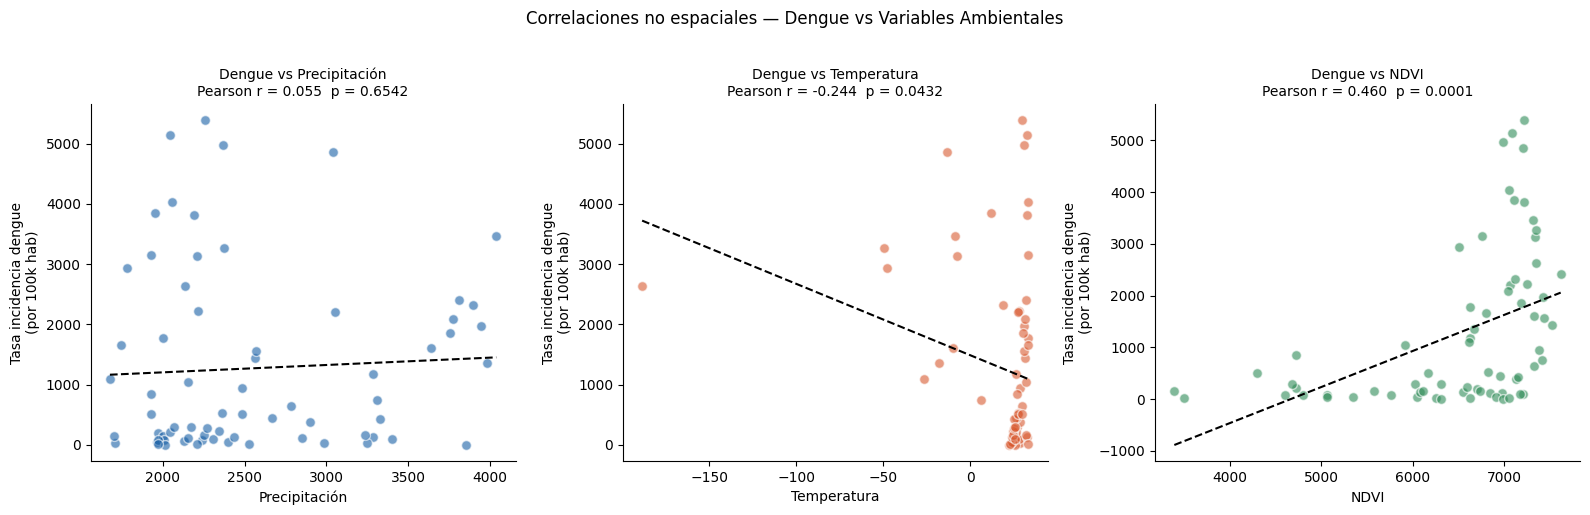

In [69]:
# Gráficos de dispersión dengue vs variables ambientales
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores_scatter = ['#185FA5', '#D85A30', '#2E8B57']

for i, (nombre, col) in enumerate(variables_amb.items()):
    datos_corr = gdf_c[['CANTÓN', 'tasa_incidencia', col]].dropna()
    r_p, p_p = stats.pearsonr(datos_corr['tasa_incidencia'], datos_corr[col])

    axes[i].scatter(datos_corr[col], datos_corr['tasa_incidencia'],
                    color=colores_scatter[i], alpha=0.6, edgecolor='white', s=50)

    # Línea de tendencia
    z = np.polyfit(datos_corr[col], datos_corr['tasa_incidencia'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(datos_corr[col].min(), datos_corr[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--')

    axes[i].set_xlabel(nombre)
    axes[i].set_ylabel('Tasa incidencia dengue\n(por 100k hab)')
    axes[i].set_title(f'Dengue vs {nombre}\nPearson r = {r_p:.3f}  p = {p_p:.4f}',
                      fontsize=10)
    axes[i].spines[['top', 'right']].set_visible(False)

plt.suptitle('Correlaciones no espaciales — Dengue vs Variables Ambientales',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Análisis bivariado espacial (I de Moran bivariada)

La I de Moran bivariada mide si los valores de dengue en un cantón
se relacionan con los valores ambientales de sus cantones vecinos.
Esto es diferente a la correlación clásica: no pregunta si el cantón
con más dengue tiene más temperatura, sino si el cantón con más dengue
está rodeado de cantones con mayor temperatura.

Esta distinción es importante para entender los mecanismos de difusión
espacial del dengue, ya que el mosquito Aedes aegypti puede desplazarse
entre cantones vecinos.

In [70]:
# I de Moran bivariada: dengue vs variables ambientales espacialmente rezagadas
print("=== I DE MORAN BIVARIADA ===")
print("Dengue vs lag espacial de variables ambientales\n")

resultados_biv = {}
for nombre, col in variables_amb.items():
    serie_dengue = gdf_c['tasa_incidencia'].fillna(gdf_c['tasa_incidencia'].mean())
    serie_amb = gdf_c[col].fillna(gdf_c[col].mean())

    m_biv = Moran_BV(serie_dengue, serie_amb, w, permutations=999)
    resultados_biv[f'Dengue vs lag({nombre})'] = {
        'I bivariada': round(m_biv.I, 4),
        'z-score': round(m_biv.z_sim, 4),
        'p-value': round(m_biv.p_sim, 4),
        'Significativo': 'Sí ✓' if m_biv.p_sim < 0.05 else 'No'
    }

df_biv = pd.DataFrame(resultados_biv).T
display(df_biv)

=== I DE MORAN BIVARIADA ===
Dengue vs lag espacial de variables ambientales



,I bivariada,z-score,p-value,Significativo
Dengue vs lag(Precipitación),0.076,0.8487,0.202,No
Dengue vs lag(Temperatura),-0.1604,-1.888,0.048,Sí ✓
Dengue vs lag(NDVI),0.3873,4.2831,0.001,Sí ✓


### 5.3 ¿Qué aporta el análisis espacial que no se ve en una tabla convencional?

La correlación de Pearson y Spearman mide la relación entre dengue y variables
ambientales EN EL MISMO CANTÓN (relación vertical). La I de Moran bivariada
mide si el dengue de un cantón se relaciona con las variables ambientales de
sus VECINOS (relación horizontal).

Resultados clave de la comparación:

1. **Precipitación:** La correlación no espacial no es significativa (r = 0.055,
   p = 0.654), pero la I bivariada tampoco lo es (I = 0.076, p = 0.202).
   Esto sugiere que la precipitación local ni la de los vecinos explica
   directamente el dengue a escala cantonal. Posiblemente la relación
   opera a escalas temporales más finas (eventos de lluvia específicos)
   que se pierden al usar promedios anuales.

2. **Temperatura:** La correlación no espacial es significativa y negativa
   (r = -0.244, p = 0.043), lo que parece contraintuitivo. Sin embargo,
   refleja el efecto de la altitud: los cantones más fríos (altura)
   tienen menos dengue. La I bivariada también es negativa y significativa
   (I = -0.160, p = 0.048), indicando que los cantones con más dengue
   tienden a estar rodeados de cantones con temperaturas más bajas.
   Esto refuerza la hipótesis altitudinal: los focos de dengue están
   en zonas bajas rodeadas de cantones de mayor altura.

3. **NDVI:** Es la variable con relación más consistente. Correlación no
   espacial significativa y positiva (r = 0.460, p = 0.0001) Y bivariada
   significativa (I = 0.387, p = 0.001). Los cantones con mayor vegetación
   tienen más dengue, Y además están rodeados de cantones con mayor
   vegetación. Esto sugiere que los ecosistemas con alta cobertura vegetal
   (zonas húmedas, tropicales) favorecen al vector de forma continua
   en el espacio.

**Conclusión metodológica:** Una tabla de correlaciones convencional habría
mostrado que la precipitación no se relaciona con el dengue y hubiera
terminado ahí. El análisis espacial permite detectar que el NDVI tiene
un patrón espacialmente estructurado que coincide con el del dengue,
algo que no es visible en un scatter plot convencional.

## Sección 6: Discusión Crítica

### 6.1 Problema de la Unidad Espacial Modificable (MAUP)

El análisis se realizó a nivel cantonal, que es solo una de las posibles
unidades espaciales de análisis. Los resultados obtenidos no son propiedades
absolutas del fenómeno del dengue, sino resultados condicionados por la
unidad espacial utilizada. Si el análisis se realizara a nivel de distrito,
área de salud o zona climática, los valores del I de Moran y los patrones
detectados podrían cambiar significativamente.

### 6.2 Cantones no contiguos y subconjunto de cantones

El análisis trabajó con 69 cantones con datos completos, no con los 84
cantones del país. Esto afecta la matriz W porque algunos cantones pueden
quedar con menos vecinos de los que tendrían en la realidad, lo que puede
subestimar o distorsionar la autocorrelación espacial detectada.

### 6.3 Escala temporal

Se utilizó el promedio del período 2000-2019 como medida de resumen.
Esta decisión permite reducir el efecto de años epidémicos aislados,
pero pierde la variabilidad interanual. Costa Rica ha tenido brotes
importantes en años específicos como 2010 y 2013, que quedan suavizados
en el promedio. Un análisis año por año o comparando años epidémicos
vs no epidémicos revelaría patrones temporales que el promedio oculta.

In [71]:
# ---------------------------------------------------------------
# SECCIÓN 6: RESUMEN FINAL
# ---------------------------------------------------------------
# Tabla resumen de todos los resultados del I de Moran

print("=== RESUMEN GENERAL DE RESULTADOS ===\n")
print("I de Moran Global:")
display(df_moran)
print("\nCorrelaciones no espaciales con dengue:")
display(df_corr)
print("\nI de Moran Bivariada:")
display(df_biv)

=== RESUMEN GENERAL DE RESULTADOS ===

I de Moran Global:


,I de Moran,z-score,p-value,Significativo (α=0.05)
Tasa incidencia dengue,0.3942,4.7869,0.0,Sí ✓
Temperatura (°C),0.0524,0.7853,0.4323,No
NDVI,0.64,7.6647,0.0,Sí ✓
Precipitación (mm),0.727,8.6827,0.0,Sí ✓



Correlaciones no espaciales con dengue:


,Pearson r,p-value Pearson,Spearman r,p-value Spearman,Significativo
Precipitación,0.0549,0.6542,0.0947,0.4389,No
Temperatura,-0.2442,0.0432,0.147,0.2282,Sí ✓
NDVI,0.4597,0.0001,0.5623,0.0,Sí ✓



I de Moran Bivariada:


,I bivariada,z-score,p-value,Significativo
Dengue vs lag(Precipitación),0.076,0.8487,0.202,No
Dengue vs lag(Temperatura),-0.1604,-1.888,0.048,Sí ✓
Dengue vs lag(NDVI),0.3873,4.2831,0.001,Sí ✓


## Conclusiones

El presente análisis exploratorio de datos espaciales permitió evaluar si
la distribución del dengue en Costa Rica presenta estructura espacial o
se distribuye aleatoriamente entre cantones.

**1. El dengue tiene estructura espacial significativa.**
La tasa de incidencia de dengue presenta una I de Moran de 0.3942
(z-score = 4.79, p < 0.001), lo que permite rechazar la hipótesis nula
de aleatoriedad espacial. Los cantones con tasas similares de dengue
tienden a agruparse geográficamente, formando clusters territoriales
coherentes con las condiciones ambientales de cada región.

**2. El cluster principal de dengue se ubica en la región Pacífica.**
Los 20 cantones Alto-Alto se concentran principalmente en Guanacaste
y el Pacífico Central y Sur (Abangares, Nicoya, Santa Cruz, Golfito,
Garabito). Esta región combina temperaturas altas, estacionalidad
climática marcada y cobertura vegetal que favorece la reproducción
del Aedes aegypti.

**3. Las variables ambientales presentan mayor autocorrelación que el dengue.**
La precipitación (I = 0.727) y el NDVI (I = 0.640) presentan
autocorrelación espacial más fuerte que el dengue mismo, lo que refleja
que los patrones climáticos y de vegetación tienen mayor continuidad
territorial que la distribución de la enfermedad, la cual depende también
de factores sociales y epidemiológicos.

**4. La temperatura no presenta autocorrelación espacial significativa.**
Con I = 0.052 y p = 0.432, la temperatura no muestra agrupamiento espacial
a escala cantonal. Esto se explica por la topografía variada de Costa Rica,
donde cantones vecinos pueden tener temperaturas muy diferentes según su altitud.

**5. El NDVI es la variable ambiental con mayor asociación con el dengue.**
Tanto la correlación no espacial (Pearson r = 0.460, p < 0.001) como
la I de Moran bivariada (I = 0.387, p = 0.001) muestran que los cantones
con mayor cobertura vegetal tienden a tener más dengue, y además están
rodeados de cantones vecinos también con mayor dengue. Esto sugiere que
los ecosistemas húmedos y tropicales favorecen la persistencia del vector.

**6. La precipitación no mostró relación significativa con el dengue.**
Ni la correlación clásica (r = 0.055, p = 0.654) ni la bivariada espacial
(I = 0.076, p = 0.202) fueron significativas. Esto puede deberse a que
la relación entre lluvia y dengue opera a escalas temporales más finas
(eventos específicos de lluvia) que se pierden al usar promedios anuales.

**7. Limitaciones del análisis.**
Los resultados deben interpretarse considerando que: (a) se trabajó con
69 de los 84 cantones por falta de datos en algunos, lo que afecta la
matriz W; (b) el uso de promedios 2000-2019 oculta la variabilidad
interanual y los años de brote epidémico; (c) los patrones detectados
son propios de la escala cantonal y podrían cambiar a nivel de distrito
o área de salud (efecto MAUP).

## Reporte de Uso de Inteligencia Artificial

De acuerdo con los lineamientos del curso, se documenta el uso de
herramientas de inteligencia artificial en este trabajo:

**Herramienta utilizada:** Claude (Anthropic)

**Usos específicos:**

1. **Fuente de datos de población:** Se consultó a la IA para identificar
   cuál era la fuente oficial más apropiada para obtener datos de población
   cantonal en Costa Rica para el período 2000-2019. La IA recomendó utilizar
   las Estimaciones y Proyecciones Subnacionales de Población del INEC,
   específicamente el archivo "Kit de cuadros 2000-2050".

2. **Limpieza de datos de precipitación:** El archivo de precipitación CHIRPS
   venía en formato diario con más de 600.000 filas y la fecha codificada
   dentro de un índice complejo. Se utilizó la IA para desarrollar el código
   de extracción de la fecha y el cálculo del promedio anual por cantón.

3. **Resolución de errores de compatibilidad:** Durante la integración de las
   fuentes de datos surgieron inconsistencias en los nombres de cantones entre
   diferentes fuentes (PAHO, INEC, SNIT). Se utilizó la IA para desarrollar
   una función de normalización de texto que facilitara la unión de los datasets.

4. **Interpretación de resultados:** Se utilizó la IA como apoyo para interpretar
   los resultados estadísticos obtenidos, incluyendo la lectura territorial del
   I de Moran, la interpretación de los cuadrantes del Moran Scatterplot y la
   diferencia entre correlación espacial y no espacial.


## Referencias bibliográficas

### Estudios base

García et al. (2023) analizaron los patrones comunes entre casos de dengue,
clima y variables ambientales locales en Costa Rica usando análisis de wavelet.
Sus hallazgos son consistentes con los resultados de este laboratorio:
identificaron que la frecuencia multinanual del dengue (ciclos de 3 años)
se correlaciona con índices climáticos oceánicos, y que esta asociación es
especialmente prominente en cantones de la costa Pacífica Norte y Sur,
así como en cantones del Pacífico Central — exactamente las zonas donde
nuestro análisis identificó el cluster Alto-Alto (HH). Además, reportaron
que el NDVI a escala fina se asocia positivamente con los casos de dengue,
lo que es consistente con nuestra I de Moran bivariada significativa entre
dengue y NDVI (I = 0.387, p = 0.001).

Bravo López (2021) provee el marco teórico para el uso del I de Moran como
herramienta de detección de autocorrelación espacial en datos geográficos.
Según este autor, un I de Moran positivo y estadísticamente significativo
indica que los valores similares tienden a agruparse espacialmente, lo que
sustenta la interpretación de nuestros resultados (I dengue = 0.3942,
z-score = 4.79, p < 0.001).

### Lista de referencias

García, Y. E., Chou-Chen, S. W., Barboza, L. A., Daza-Torres, M. L.,
Montesinos-López, J. C., Vásquez, P., Calvo, J. G., Nuño, M., y Sanchez, F.
(2023). Common patterns between dengue cases, climate, and local environmental
variables in Costa Rica: A wavelet approach. PLOS Global Public Health, 3(10),
e0002417.  https://journals.plos.org/globalpublichealth/article?id=10.1371/journal.pgph.0002417

Bravo López, P. E. (2021). Autocorrelación espacial — Índices para determinar
su presencia en datos geográficos: Breve revisión de la literatura.
Universidad-Verdad, (78), 48–61.
https://revistas.uazuay.edu.ec/index.php/udaver/article/view/351

### Fuentes de datos

- Casos de dengue: Organización Panamericana de la Salud (PAHO)
- Población cantonal: Instituto Nacional de Estadística y Censos de Costa Rica
  (INEC). Estimaciones y proyecciones subnacionales de población 2000-2050.
  Kit de cuadros. https://www.inec.cr
- Geometrías cantonales: Sistema Nacional de Información Territorial (SNIT)
  de Costa Rica. https://www.snitcr.go.cr
- Precipitación: CHIRPS — Climate Hazards Group InfraRed Precipitation
  with Station data. Google Earth Engine.
- Temperatura LST: MODIS MOD11A2. Google Earth Engine.
- NDVI: MODIS MOD13A3. Google Earth Engine.